In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numba import njit
import bayesflow as bf
from pathlib import Path

import pickle
import pandas as pd

from benchmark.examples.gaussian.config import (
    ASSUMED_MODELS,
    SOURCE_MODELS,
)



INFO:bayesflow:Using backend 'tensorflow'


In [2]:
rng = np.random.default_rng(seed=2026)

In [3]:
N_OBS = 10
N_DIM = 20
# Each dimension has an independent mean drawn from the model's prior.
PRIOR_PARAMS = [
    (0.0, 1.0),
    (3.0, 1.0),
    (0.0, 1.0),
    (0.1, 1.0),
]
LIKELIHOOD_STDS = [1.0, 1.0, 3.0, 1.0]


In [4]:
def prior_1():
    return dict(mu=rng.normal(*PRIOR_PARAMS[0], size=N_DIM))
def prior_2():
    return dict(mu=rng.normal(*PRIOR_PARAMS[1], size=N_DIM))
def prior_3():
    return dict(mu=rng.normal(*PRIOR_PARAMS[2], size=N_DIM))
def prior_4():
    return dict(mu=rng.normal(*PRIOR_PARAMS[3], size=N_DIM))

def likelihood_1(mu, **kwargs):
    x = rng.normal(loc=mu, scale=1.0, size=(N_OBS, N_DIM)).astype(np.float32)
    return dict(x=x)
def likelihood_2(mu, **kwargs):
    x = rng.normal(loc=mu, scale=3.0, size=(N_OBS, N_DIM)).astype(np.float32)
    return dict(x=x)

simulators = [
    bf.make_simulator([prior_1, likelihood_1]),
    bf.make_simulator([prior_2, likelihood_1]),
    bf.make_simulator([prior_3, likelihood_2]),
    bf.make_simulator([prior_4, likelihood_1]),
]


In [5]:
def log_marginal_likelihood(x, mu0, tau, sigma):
    x = np.asarray(x, dtype=np.float64)
    n = x.shape[0]
    sig2, tau2 = sigma**2, tau**2
    x_bar = x.mean(axis=0)
    ss_within = np.sum((x - x_bar)**2, axis=0)

    logdet = (n - 1) * np.log(sig2) + np.log(sig2 + n * tau2)
    quad = ss_within / sig2 + n * (x_bar - mu0)**2 / (sig2 + n * tau2)
    logp_per_dim = -0.5 * (n * np.log(2 * np.pi) + logdet + quad)
    return float(np.sum(logp_per_dim))


def compute_true_log_bfs(test_data, reference=0):
    x_batch = np.asarray(test_data["x"], dtype=np.float64)
    num_models = len(PRIOR_PARAMS)
    log_ml = np.empty((x_batch.shape[0], num_models), dtype=np.float64)

    for k, (mu0, tau) in enumerate(PRIOR_PARAMS):
        sigma = LIKELIHOOD_STDS[k]
        for b, x in enumerate(x_batch):
            log_ml[b, k] = log_marginal_likelihood(x, mu0, tau, sigma)

    competing = [k for k in range(num_models) if k != reference]
    return log_ml[:, competing] - log_ml[:, [reference]]


In [6]:
workflow = bf.ModelComparisonWorkflow(
    simulator=simulators,
    summary_variables="x",
    summary_network=bf.networks.DeepSet(summary_dim = 12),
    scoring_rules="logistic",
    initial_learning_rate=1e-3
)

In [7]:
val_data = workflow.simulate(1000)

In [8]:
history = workflow.fit_online(epochs=200, num_batches_per_epoch=64, batch_size=256, validation_data=val_data)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - ScoringRuleNetwork/scoring_rule: 1.2104 - loss: 1.2104 - val_ScoringRuleNetwork/scoring_rule: 0.6308 - val_loss: 0.6308
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - ScoringRuleNetwork/scoring_rule: 0.4581 - loss: 0.4581 - val_ScoringRuleNetwork/scoring_rule: 0.3511 - val_loss: 0.3511
Epoch 3/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - ScoringRuleNetwork/scoring_rule: 0.3571 - loss: 0.3571 - val_ScoringRuleNetwork/scoring_rule: 0.3535 - val_loss: 0.3535
Epoch 4/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - ScoringRuleNetwork/scoring_rule: 0.3454 - loss: 0.3454 - val_ScoringRuleNetwork/scoring_rule: 0.3450 - val_loss: 0.3450
Epoch 5/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - ScoringRuleNetwork/scoring_rule: 0.3511 - loss: 0.3511 - val_ScoringRuleNetwork/scoring_rule: 0.3402 - val_loss: 0.3402
Epoch 6/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - ScoringRuleNetwork/scoring_rule: 0.3430 - loss: 0.3430 - val_ScoringRuleNet

INFO:bayesflow:Training completed in 12.36 minutes.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimating completed in 0.21 seconds.


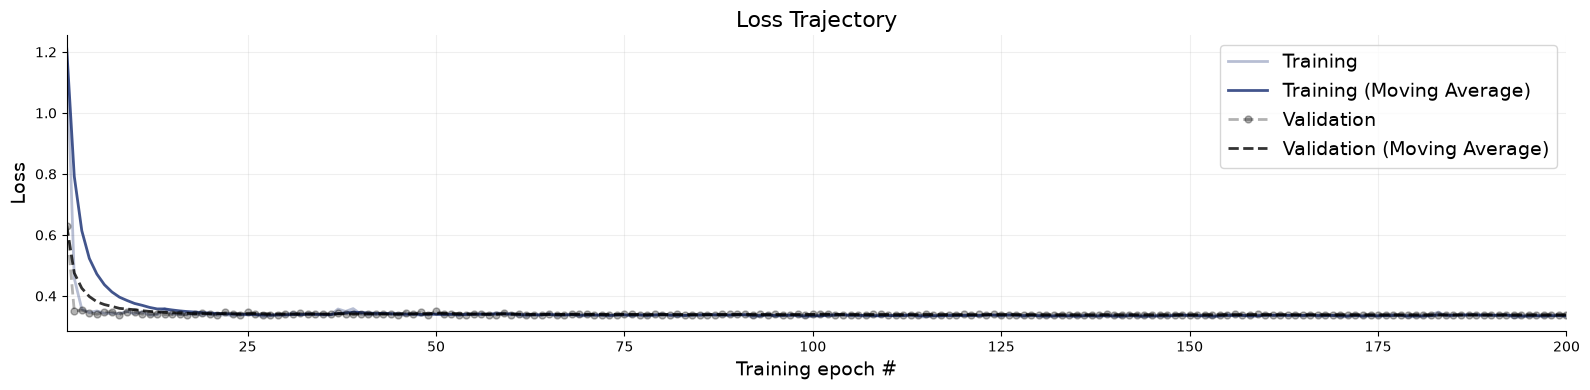

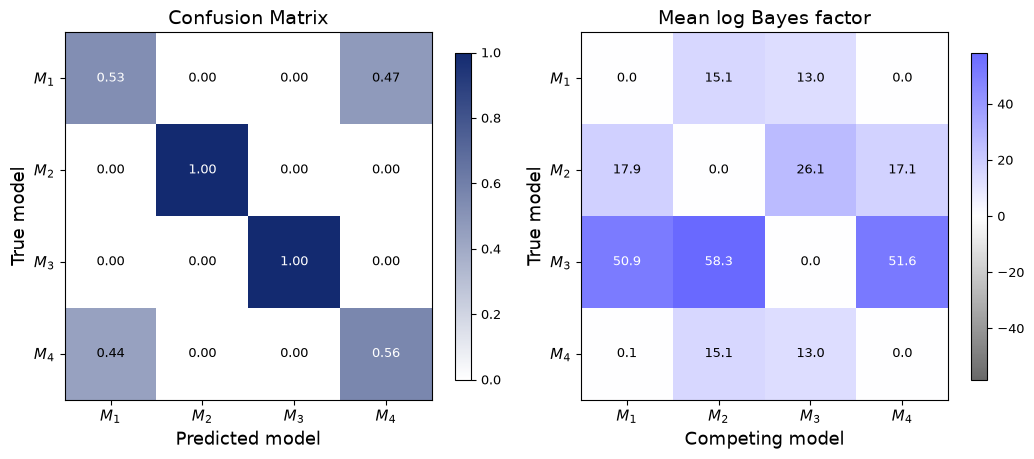

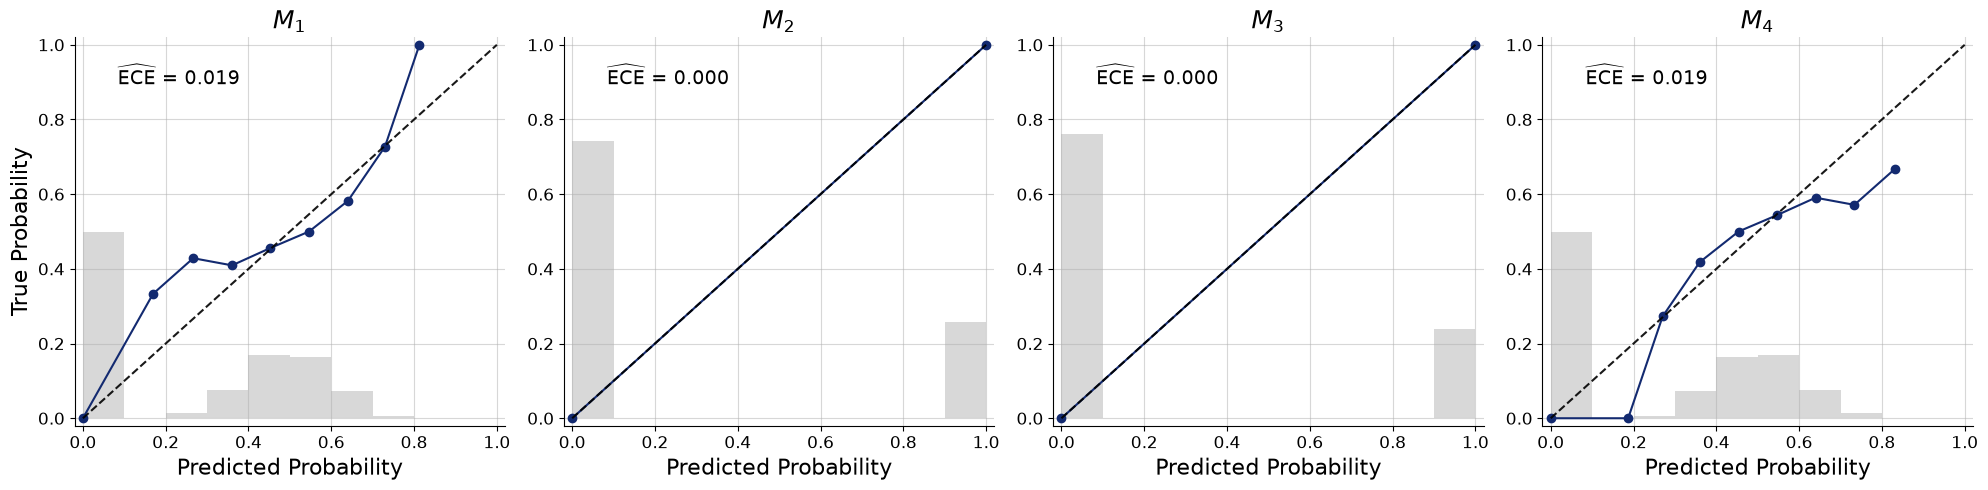

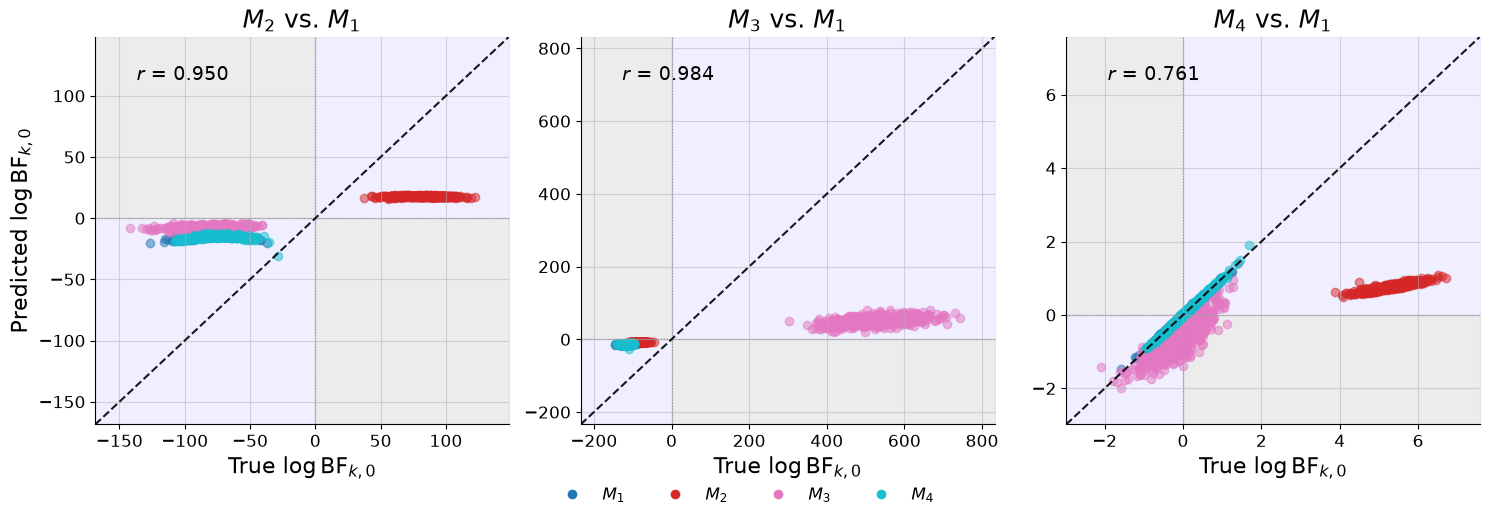

In [9]:
figures = workflow.plot_default_diagnostics(test_data=2000, true_log_bfs_fn=compute_true_log_bfs)

In [10]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks/direct_logistic.keras")
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [ ]:
# Indirect S=4D caches supply the shared observations and reference PMPs.
# Direct predictions have their own output root, independent of this input path.
RESULTS_DIR = Path(
    "/Users/yimingzang/Documents/Project/benchmark2/"
    "benchmark/examples/gaussian/results"
)
INDIRECT_DATASET_DIR = RESULTS_DIR / "ood_80d_10n" / "datasets"
DIRECT_RESULTS_DIR = RESULTS_DIR / "direct"


In [ ]:
all_items = []

for source in SOURCE_MODELS:
    with open(INDIRECT_DATASET_DIR / f"{source}_logml_pmp.pkl", "rb") as f:
        items = pickle.load(f)

    for item in items:
        all_items.append((source, item))

x_batch = np.stack(
    [item["x"] for source, item in all_items],
    axis=0,
).astype(np.float32)

print(x_batch.shape)

In [ ]:
estimates = workflow.estimate(
    conditions={"x": x_batch}
)

p_direct = np.asarray(
    estimates["model_probs"]
)

In [ ]:
# Export all 600 predictions together with the matching gold / indirect PMPs.
# Run the two preceding data-loading and prediction cells before this cell.
import json
import pathlib
from datetime import datetime, timezone
from scipy.special import softmax

model_order = tuple(ASSUMED_MODELS)
assert model_order == ("m1", "m2", "m3", "m4")
assert len(all_items) == 600
assert x_batch.shape == (600, 10, 20)
np.testing.assert_array_equal(
    x_batch,
    np.stack([item["x"] for source, item in all_items]).astype(np.float32),
)

p_gold = softmax(np.array([
    [item[f"gold_log_marginal_{model}"] for model in model_order]
    for source, item in all_items
], dtype=np.float64), axis=1)
p_indirect = softmax(np.array([
    [item[f"npe_log_marginal_{model}"] for model in model_order]
    for source, item in all_items
], dtype=np.float64), axis=1)
p_direct = np.asarray(p_direct, dtype=np.float64)

for method, probabilities in {
    "gold": p_gold, "indirect": p_indirect, "direct": p_direct
}.items():
    assert probabilities.shape == (600, 4), method
    assert np.isfinite(probabilities).all(), method
    assert ((probabilities >= 0) & (probabilities <= 1)).all(), method
    np.testing.assert_allclose(probabilities.sum(axis=1), 1.0, rtol=0, atol=1e-6)

comparison = pd.DataFrame({
    "source_model": [source for source, item in all_items],
    "id": [int(item["id"]) for source, item in all_items],
})
assert not comparison.duplicated(["source_model", "id"]).any()
source_counts = comparison.groupby("source_model").size().reindex(SOURCE_MODELS)
assert source_counts.eq(50).all()

for j, model in enumerate(model_order):
    comparison[f"p_gold_{model}"] = p_gold[:, j]
    comparison[f"p_indirect_{model}"] = p_indirect[:, j]
    comparison[f"p_direct_{model}"] = p_direct[:, j]
comparison["l1_indirect"] = np.abs(p_indirect - p_gold).sum(axis=1)
comparison["l1_direct"] = np.abs(p_direct - p_gold).sum(axis=1)

COMPARISON_DIR = DIRECT_RESULTS_DIR / "direct_logistic"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = COMPARISON_DIR / "pmp_comparison.csv"
comparison.to_csv(CSV_PATH, index=False)
metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "num_datasets": len(comparison),
    "input_shape": list(x_batch.shape),
    "model_order": list(model_order),
    "model_prior": [0.25] * 4,
    "source_counts": {source: int(count) for source, count in source_counts.items()},
    "loss_function": "logistic",
    "direct_checkpoint": str(filepath.resolve()),
    "direct_source": "p_direct from the preceding workflow.estimate cell",
    "indirect_source": "S=4D: softmax of existing npe_log_marginal_m1..m4 in ood_80d_10n; NPE inference was not rerun",
    "indirect_summary_dimension": 80,
    "indirect_summary_multiplier": 4,
    "gold_source": "softmax of existing analytical gold_log_marginal_m1..m4",
    "dataset_directory": str(pathlib.Path(INDIRECT_DATASET_DIR).resolve()),
    "input_files": [f"{source}_logml_pmp.pkl" for source in SOURCE_MODELS],
}
CSV_PATH.with_suffix(".metadata.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
print(f"Saved {len(comparison)} datasets with four PMPs per method: {CSV_PATH}")
comparison.head()
